In [1]:
import json

import pdal
import laspy
import numpy as np
import matplotlib.pyplot as plt
import alphashape
import geopandas as gpd

from shapely.geometry import Point
from src.functions import estimer_z_toit, triangle_max_edge_length
from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree, Delaunay

In [2]:
laz_path = "../data/tuile_1.laz"
las = laspy.read(laz_path)

x = las.x
y = las.y
z = las.z

crs = las.header.parse_crs()

nb_points = len(las.points)
surface_xy = (x.max() - x.min()) * (y.max() - y.min())
densite = nb_points / surface_xy

classes = np.array(las.classification)
unique_classes, count = np.unique(classes, return_counts=True)

buildings = classes == 6

x_buildings = x[buildings]
y_buildings = y[buildings]
z_buildings = z[buildings]

In [3]:
print("----- Résumé des données -----")

print('Nombre de points : ', len(las.points))
print('Version : ', las.header.version)
print('Format des points : ', las.header.point_format)
print('CRS : ', crs.to_epsg())

print('Xmin : ', x.min(), ' Xmax : ', x.max())
print('Ymin : ', y.min(), ' Ymax : ', y.max())
print('Zmin : ', z.min(), ' Zmax : ', z.max(), "Différence d'altitude : ", z.max() - z.min())

print('Densité moyenne : ', densite, "points / m²")


print('----- Répartition des classes -----')
for c, n in zip(unique_classes, count):
    print("Classe", c, " : ", n, "Points")

----- Résumé des données -----
Nombre de points :  18330487
Version :  1.4
Format des points :  <PointFormat(6, 0 bytes of extra dims)>
CRS :  2154
Xmin :  628000.0  Xmax :  628999.99
Ymin :  6881000.0  Ymax :  6881999.99
Zmin :  54.11  Zmax :  135.04 Différence d'altitude :  80.92999999999999
Densité moyenne :  18.330853615235295 points / m²
----- Répartition des classes -----
Classe 1  :  836293 Points
Classe 2  :  8581607 Points
Classe 3  :  195901 Points
Classe 4  :  463438 Points
Classe 5  :  4834421 Points
Classe 6  :  3416815 Points
Classe 67  :  2012 Points


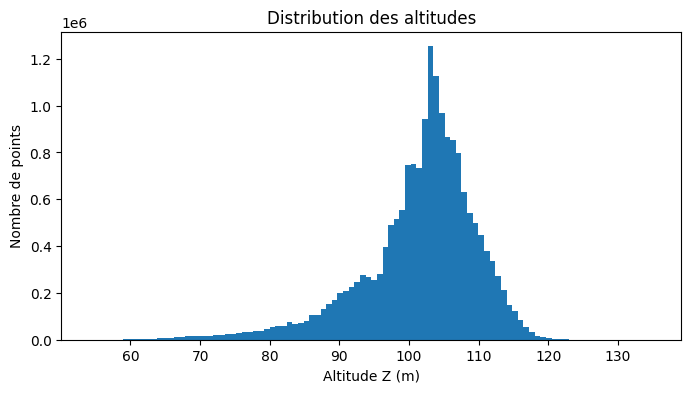

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(z, bins=100)
plt.xlabel("Altitude Z (m)")
plt.ylabel("Nombre de points")
plt.title("Distribution des altitudes")
plt.show()

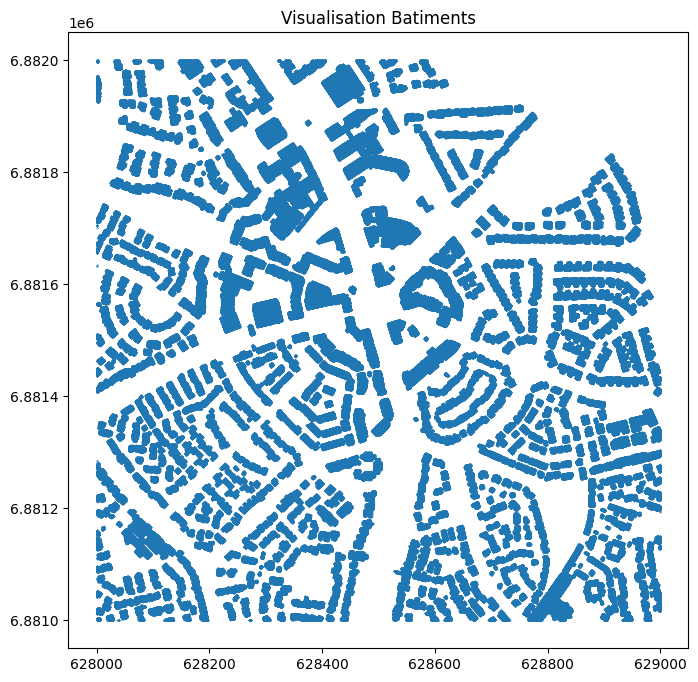

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(x_buildings, y_buildings, s=0.01)
plt.title("Visualisation Batiments")
plt.show()

In [6]:
xy_buildings = np.column_stack([x_buildings, y_buildings])

cluster = DBSCAN(
    eps=0.7,
    min_samples=10,
    # La calibration est faite à la main
).fit(xy_buildings)

labels = cluster.labels_
unique_labels = np.unique(labels)
n_clusters = np.sum(unique_labels != -1)
n_noise = np.sum(labels == -1)

Nombre de clusters batiments :  1101
Nombre de points bruit :  253


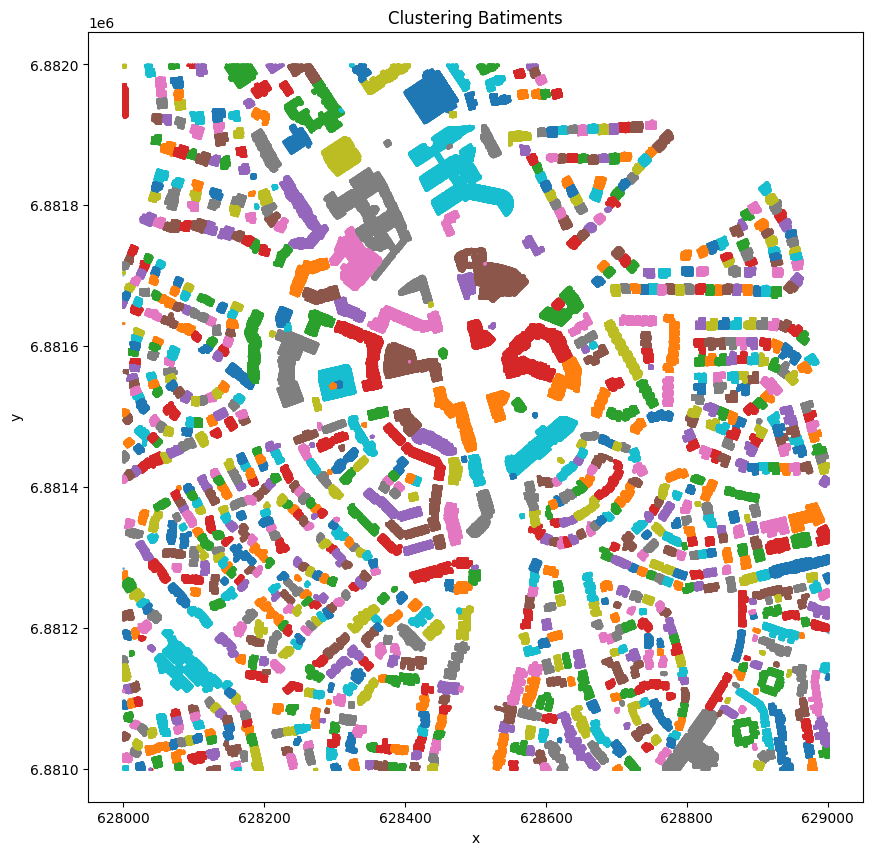

In [7]:
print('Nombre de clusters batiments : ', n_clusters)
print('Nombre de points bruit : ', n_noise)

plt.figure(figsize=(10, 10))

for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(x_buildings[mask], y_buildings[mask], s=0.2, alpha=0.2, label="bruit")
    else:
        plt.scatter(x_buildings[mask], y_buildings[mask], s=0.4)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Clustering Batiments')
plt.axis('equal')
plt.show()

In [8]:
emprises = []
emprises_id = []
emprises_nb_pts = []

for label in unique_labels:

    if label == -1:
        continue

    mask = labels == label
    nb_pts = np.sum(mask)

    if nb_pts < 100:  # Disons qu'un cluster de moins de 100 points n'est pas un batiment mais du bruit mal catégorisé
        continue

    x_emprise = x_buildings[mask]
    y_emprise = y_buildings[mask]
    xy_emprise = np.column_stack([x_emprise, y_emprise])

    geom = alphashape.alphashape(xy_emprise, alpha=0.5)

    emprises.append(geom)
    emprises_id.append(int(label))
    emprises_nb_pts.append(int(nb_pts))

print("Nombre d'emprises batiments : ", len(emprises))

Nombre d'emprises batiments :  1091


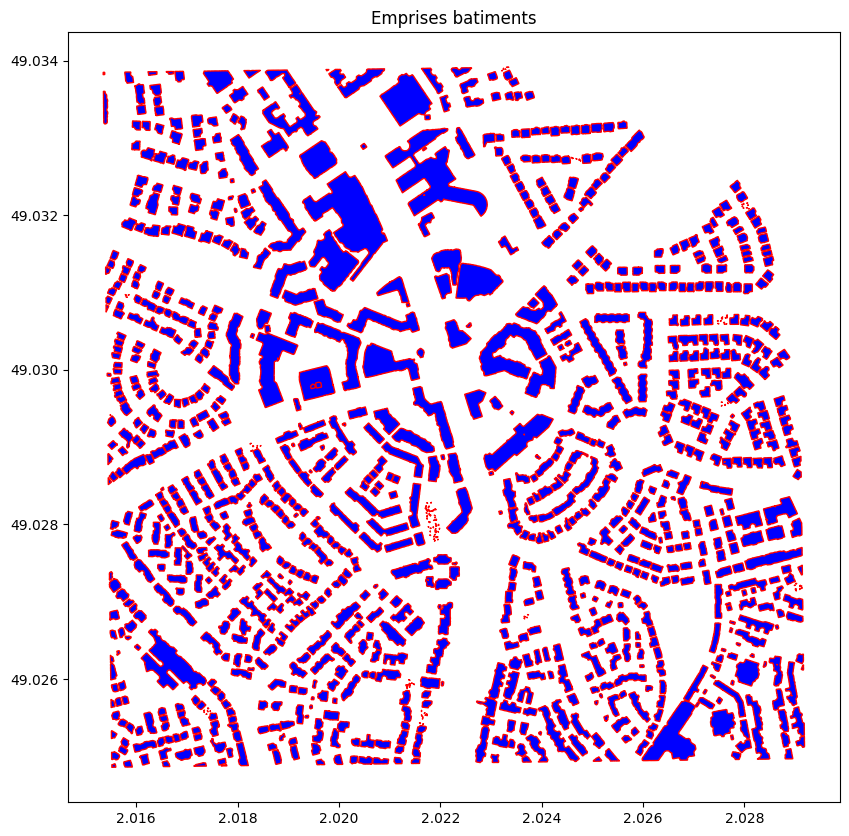

In [9]:
geojson = gpd.GeoDataFrame(
    {
        "building_id": emprises_id,
        "n_points": emprises_id,
    },
    geometry=emprises,
    crs=las.header.parse_crs()
)

geojson = geojson.to_crs("EPSG:4326")

ax = geojson.plot(figsize=(10, 10), edgecolor='red', facecolor='blue')
ax.set_title('Emprises batiments')
plt.show()

In [10]:
geojson_path = "../outputs/pipeline_complet/footprint.geojson"
geojson.to_file(geojson_path, driver='GeoJSON')

print("GeoJSON écrit :", geojson_path)

GeoJSON écrit : ../outputs/pipeline_complet/footprint.geojson


In [11]:
building_id = 933  # Je choisis ma maison
emprise = geojson.to_crs("EPSG:2154").iloc[building_id].geometry

In [12]:
maison = emprise.buffer(2)
maison = maison.wkt

pipeline_dict = [
    laz_path,
    {
        "type": "filters.crop",
        'polygon': maison
    }
]

pipeline_json = json.dumps(pipeline_dict)
pipeline = pdal.Pipeline(pipeline_json)
pipeline.execute()

result = pipeline.arrays[0]

In [13]:
X = result['X']
Y = result['Y']
Z = result['Z']
Classification = result['Classification']

maison_mask = Classification == 6
sol_mask = Classification == 2

x_m, y_m, z_m = X[maison_mask], Y[maison_mask], Z[maison_mask]
x_s, y_s, z_s = X[sol_mask], Y[sol_mask], Z[sol_mask]

z_sol = float(np.median(z_s))

emprise_coords = np.array(emprise.exterior.coords)


In [14]:
print('Nombre de points extraits : ', len(result))
print('Points bâtiments : ', len(x_m))
print('Points sol : ', len(x_s))
print('Type de géométrie : ', emprise.geom_type)
print('Surface : ', emprise.area)
print('Altitude (m) : ', z_sol)
print('Nombre de sommet du contour : ', len(emprise_coords))


Nombre de points extraits :  5284
Points bâtiments :  2892
Points sol :  1361
Type de géométrie :  Polygon
Surface :  154.40605000215157
Altitude (m) :  96.29
Nombre de sommet du contour :  46


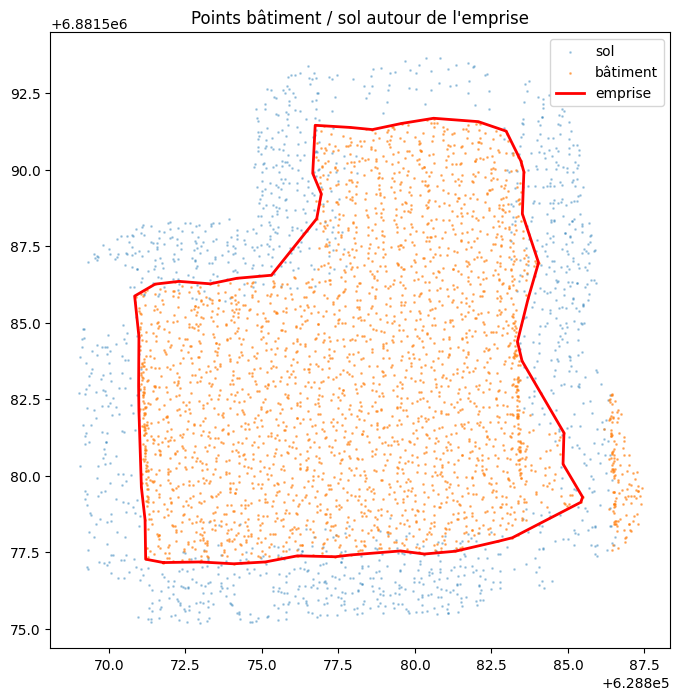

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(x_s, y_s, s=1, alpha=0.3, label="sol")
ax.scatter(x_m, y_m, s=1, alpha=0.5, label="bâtiment")
x_fp, y_fp = emprise.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2, label="emprise")

ax.set_title("Points bâtiment / sol autour de l'emprise")
ax.legend()
ax.axis("equal")
plt.show()

In [16]:
toit_tree = cKDTree(np.column_stack([x_m, y_m]))
emprise_haut = []

for xy in emprise_coords:
    z_temp = estimer_z_toit(xy, toit_tree, z_m)
    emprise_haut.append([xy[0], xy[1], z_temp])

emprise_haut = np.array(emprise_haut)
emprise_sol = np.column_stack([
    emprise_coords[:, 0],
    emprise_coords[:, 1],
    np.full(len(emprise_coords), z_sol)
])

toit_points = np.column_stack([x_m, y_m, z_m])
toit_points_all = np.vstack([toit_points, emprise_sol])

xy_toit = toit_points_all[:, :2]
tri = Delaunay(xy_toit)
triangles = tri.simplices

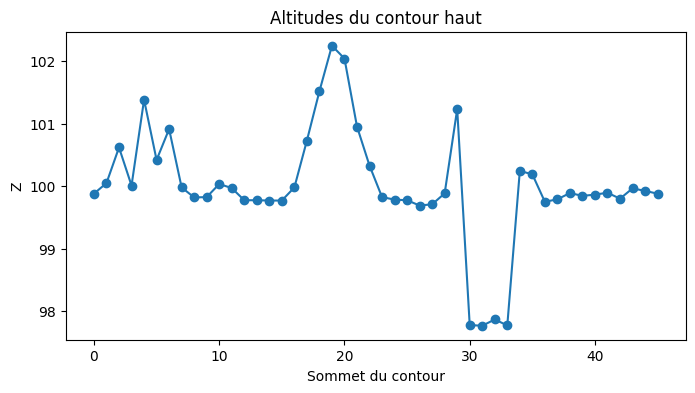

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(emprise_haut[:, 2], marker="o")
plt.title("Altitudes du contour haut")
plt.xlabel("Sommet du contour")
plt.ylabel("Z")
plt.show()

In [18]:
triangles_clean = []

for triangle in triangles:
    triangle_coords = xy_toit[triangle]
    centre = triangle_coords.mean(axis=0)

    if emprise.contains(Point(centre[0], centre[1])):
        triangles_clean.append(triangle)

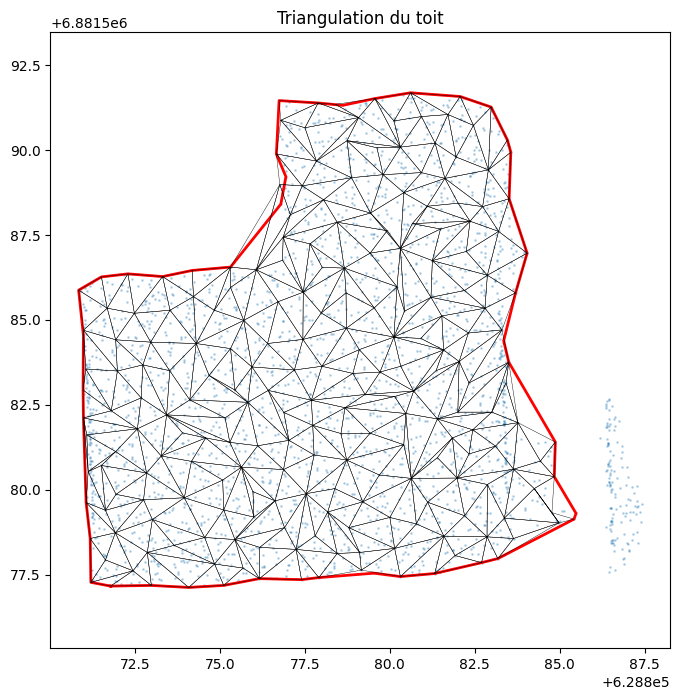

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x_m, y_m, s=1, alpha=0.25)

x_fp, y_fp = emprise.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2)

for triangle in triangles_clean:
    pts = xy_toit[triangle]
    pts_closed = np.vstack([pts, pts[0]])
    ax.plot(pts_closed[:, 0], pts_closed[:, 1], color="black", linewidth=0.3)

ax.set_title("Triangulation du toit")
ax.axis("equal")
plt.show()

In [20]:
sommets = []
sommets_map = {}


def ajout_sommet(s, precision=3):
    cle = tuple(np.round(s, precision))
    if cle not in sommets_map:
        sommets_map[cle] = len(sommets)
        sommets.append(list(map(float, s)))
    return sommets_map[cle]

sol = [ajout_sommet(s) for s in emprise_sol]
murs = []
toit = []

n = len(emprise_coords)
for i in range(n):
    j = (i + 1) % n

    g1 = ajout_sommet(emprise_sol[i])
    g2 = ajout_sommet(emprise_sol[j])
    t2 = ajout_sommet(emprise_haut[j])
    t1 = ajout_sommet(emprise_haut[i])

    murs.append([g1, g2, t2, t1])

for triangle in triangles_clean:
    surface = []
    for coord in triangle:
        s = toit_points_all[coord]
        surface.append(ajout_sommet(s))
    toit.append(surface)

In [21]:
boundaries = []
semantic_surfaces = []
semantic_values = []

# Toit
for surf in toit:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "RoofSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# Murs
for surf in murs:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "WallSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# Sol
boundaries.append([sol])
semantic_surfaces.append({"type": "GroundSurface"})
semantic_values.append(len(semantic_surfaces) - 1)

In [22]:
sommets_np = np.array(sommets, dtype=float)

scale = np.array([0.001, 0.001, 0.001], dtype=float)
translate = sommets_np.min(axis=0)

sommets_encoded = np.round((sommets_np - translate) / scale).astype(int)

In [23]:
print("Nombre total de surfaces :", len(boundaries))
print("Nombre de sommets :", len(sommets_encoded))
print("Translate :", translate)
print("Scale :", scale)

Nombre total de surfaces : 448
Nombre de sommets : 295
Translate : [6.28870840e+05 6.88157712e+06 9.62900000e+01]
Scale : [0.001 0.001 0.001]


In [24]:
cityjson = {
    "type": "CityJSON",
    "version": "2.0",
    "CityObjects": {
        f"CityJSON_1": {
            "type": "Building",
            "geometry": [
                {
                    "type": "MultiSurface",
                    "lod": "2",
                    "boundaries": boundaries,
                    "semantics": {
                        "surfaces": semantic_surfaces,
                        "values": semantic_values
                    }
                }
            ]
        }
    },
    "transform": {
        "scale": scale.tolist(),
        "translate": translate.tolist()
    },
    "vertices": sommets_encoded.tolist(),
    "metadata": {
        "identifier": f"CityJSON_1",
        "referenceSystem": "http://www.opengis.net/def/crs/EPSG/0/2154"
    }
}

cityjson_path = f"../outputs/pipeline_complet/CityJSON.json"

with open(cityjson_path, "w", encoding="utf-8") as f:
    json.dump(cityjson, f, indent=2)

print("CityJSON écrit :", cityjson_path)

CityJSON écrit : ../outputs/pipeline_complet/CityJSON.json


In [25]:
gdf = geojson.to_crs("EPSG:2154")
footprint = gdf.iloc[building_id].geometry
crop_wkt = footprint.buffer(1.0).wkt

In [26]:
pipeline_dict = [
    laz_path,
    {
        "type": "filters.crop",
        "polygon": crop_wkt
    },
    {
        "type": "filters.outlier",
        "method": "statistical",
        "mean_k": 12,
        "multiplier": 2.0
    },
    {
        "type": "filters.expression",
        "expression": "Classification !=7"
    }
]

pipeline_ground = [
    laz_path,
    {
        "type": "filters.crop",
        "polygon": footprint.buffer(6.0).wkt
    },
    {
        "type": "filters.outlier",
        "method": "statistical",
        "mean_k": 12,
        "multiplier": 2.0
    },
    {
        "type": "filters.smrf",
        "returns": "last,only",
        "where": "Classification != 7",
        "slope": 0.2,
        "threshold": 0.45,
        "window": 16.0,
        "cell": 1.0
    }
]

pipeline = pdal.Pipeline(json.dumps(pipeline_dict))
pipeline.execute()
arr = pipeline.arrays[0]
pipe_ground = pdal.Pipeline(json.dumps(pipeline_ground))
pipe_ground.execute()
arr_ground = pipe_ground.arrays[0]

Xg = arr_ground["X"]
Yg = arr_ground["Y"]
Zg = arr_ground["Z"]
Cg = arr_ground["Classification"]

X = arr["X"]
Y = arr["Y"]
Z = arr["Z"]
C = arr["Classification"]

building_mask = C == 6

xb = X[building_mask]
yb = Y[building_mask]
zb = Z[building_mask]

ground_mask = Cg == 2
z_ground = float(np.median(Zg[ground_mask]))
z_norm = zb - z_ground

roof_mask = z_norm > 2

xr = xb[roof_mask]
yr = yb[roof_mask]
zr = zb[roof_mask]

zr_norm = z_norm[roof_mask]


In [27]:
print("Points nettoyés : ", len(arr))
print(arr.dtype.names)
print("Points sol :", np.sum(ground_mask))
print("z_ground =", z_ground)
print("Points de toit conservés :", len(xr))

Points nettoyés :  3803
('X', 'Y', 'Z', 'Intensity', 'ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'Classification', 'Synthetic', 'KeyPoint', 'Withheld', 'Overlap', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'ScanChannel')
Points sol : 4317
z_ground = 96.3
Points de toit conservés : 2574


In [28]:
xyz_roof = np.column_stack([xr, yr, zr])
xy_roof = xyz_roof[:, :2]

xy_footprint = np.array(footprint.exterior.coords[:-1])
xy_roof = np.vstack([xy_roof, xy_footprint])

tri = Delaunay(xy_roof)
triangles = tri.simplices

roof_triangles_idx = []

for simplex in triangles:
    pts2d = xy_roof[simplex]
    centroid = pts2d.mean(axis=0)

    if not footprint.contains(Point(centroid[0], centroid[1])):
        continue

    if triangle_max_edge_length(pts2d) > 5:
        continue

    roof_triangles_idx.append(simplex)

footprint_coords = np.array(footprint.exterior.coords[:-1])
ground_ring = np.column_stack([
    footprint_coords[:, 0],
    footprint_coords[:, 1],
    np.full(len(footprint_coords), z_ground)
])

top_ring = []
roof_tree = cKDTree(np.column_stack([xr, yr]))

for xy in footprint_coords:
    z_top = estimer_z_toit(xy, roof_tree, zr)
    top_ring.append([xy[0], xy[1], z_top])

top_ring = np.array(top_ring)
xyz_roof = np.vstack([xyz_roof, top_ring])

In [29]:
print("Triangles bruts :", len(triangles))
print("Triangles conservés :", len(roof_triangles_idx))
print("Nombre de sommets hauts : ", len(top_ring))


Triangles bruts : 411
Triangles conservés : 383
Nombre de sommets hauts :  45


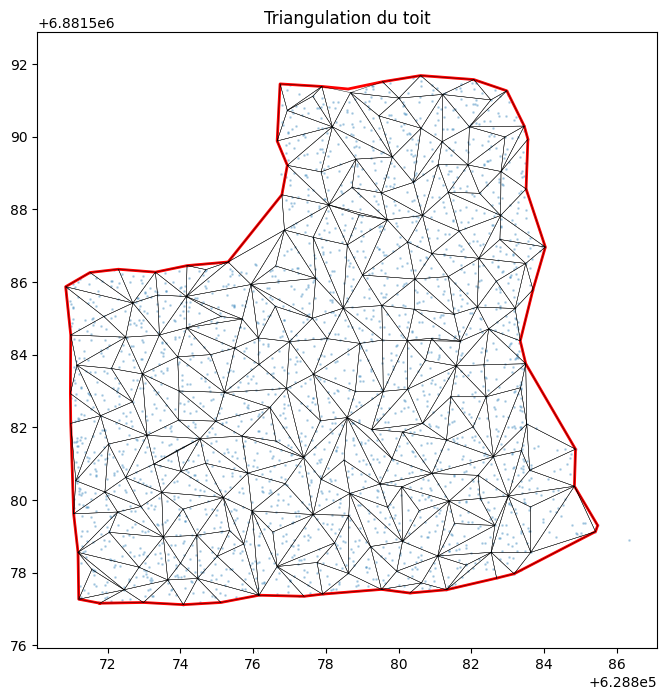

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(xb, yb, s=1, alpha=0.25)

x_fp, y_fp = footprint.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2)

for simplex in roof_triangles_idx:
    pts = xy_roof[simplex]
    pts_closed = np.vstack([pts, pts[0]])
    ax.plot(pts_closed[:, 0], pts_closed[:, 1], color="black", linewidth=0.3)

ax.set_title("Triangulation du toit")
ax.axis("equal")
plt.show()

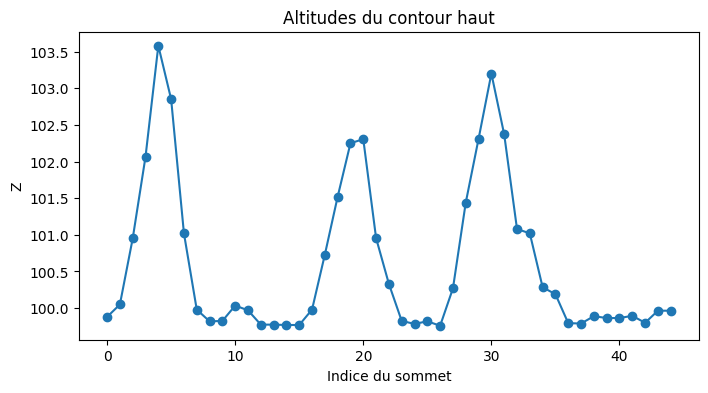

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(top_ring[:, 2], marker="o")
plt.title("Altitudes du contour haut")
plt.xlabel("Indice du sommet")
plt.ylabel("Z")
plt.show()

In [32]:
vertices = []
vertex_map = {}


def add_vertex(v, precision=3):
    key = tuple(np.round(v, precision))
    if key not in vertex_map:
        vertex_map[key] = len(vertices)
        vertices.append(list(map(float, v)))
    return vertex_map[key]

ground_surface = [add_vertex(v) for v in ground_ring]
wall_surfaces = []
roof_surfaces = []

n = len(footprint_coords)
for i in range(n):
    j = (i + 1) % n

    g1 = add_vertex(ground_ring[i])
    g2 = add_vertex(ground_ring[j])
    t2 = add_vertex(top_ring[j])
    t1 = add_vertex(top_ring[i])

    wall_surfaces.append([g1, g2, t2, t1])

for simplex in roof_triangles_idx:
    surface = []
    for idx in simplex:
        v = xyz_roof[idx]
        surface.append(add_vertex(v))
    roof_surfaces.append(surface)

In [33]:
boundaries = []
semantic_surfaces = []
semantic_values = []

# RoofSurface
for surf in roof_surfaces:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "RoofSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# WallSurface
for surf in wall_surfaces:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "WallSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# GroundSurface
boundaries.append([ground_surface])
semantic_surfaces.append({"type": "GroundSurface"})
semantic_values.append(len(semantic_surfaces) - 1)

vertices_np = np.array(vertices, dtype=float)

scale = np.array([0.001, 0.001, 0.001], dtype=float)
translate = vertices_np.min(axis=0)

vertices_encoded = np.round((vertices_np - translate) / scale).astype(int)

In [34]:
print("Nombre de murs :", len(wall_surfaces))
print("Nombre total de surfaces :", len(boundaries))
print("Nombre total de sommets :", len(vertices_encoded))
print("scale =", scale)
print("translate =", translate)

Nombre de murs : 45
Nombre total de surfaces : 429
Nombre total de sommets : 278
scale = [0.001 0.001 0.001]
translate = [6.28870840e+05 6.88157712e+06 9.63000000e+01]


In [35]:
building_id = "CityJSON_clean"

cityjson = {
    "type": "CityJSON",
    "version": "2.0",
    "CityObjects": {
        building_id: {
            "type": "Building",
            "geometry": [
                {
                    "type": "MultiSurface",
                    "lod": "2",
                    "boundaries": boundaries,
                    "semantics": {
                        "surfaces": semantic_surfaces,
                        "values": semantic_values
                    }
                }
            ]
        }
    },
    "transform": {
        "scale": scale.tolist(),
        "translate": translate.tolist()
    },
    "vertices": vertices_encoded.tolist(),
    "metadata": {
        "identifier": building_id,
        "referenceSystem": "http://www.opengis.net/def/crs/EPSG/0/2154"
    }
}

cityjson_path = "../outputs/pipeline_complet/CityJSON_clean.city.json"

with open(cityjson_path, "w", encoding="utf-8") as f:
    json.dump(cityjson, f, indent=2)

print("CityJSON écrit :", cityjson_path)

CityJSON écrit : ../outputs/pipeline_complet/CityJSON_clean.city.json
